In [27]:
%load_ext autoreload
%autoreload 2
import os
import json
import torch
import pycolmap
import numpy as np
import PIL.Image as Image
import matplotlib.pyplot as plt
import torchvision.transforms as T

from mylib.plot import plot_imgs

import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
def image_to_ts(ts_path):
    with open(ts_path, "r") as f: 
        data = f.read()
    lines = data.replace(","," ").replace("\t"," ").split("\n") 

    name_to_ts = {}
    for l in lines:
        comp = l.split(" ")
        name_to_ts[f"1/{comp[-1]}"] = comp[0]
    

    return name_to_ts

In [29]:
dataset = 0

dataset_dictionary = {
    0 : "TUM_RGBD",
    1 : "ScanNet"
}
dataset_test = dataset_dictionary[dataset]

In [30]:
# path =  "/media/leonardo/Leo_HD/data/EPO_track/ScanNet/data/scans/scene0000_00/data/1"

# recon = pycolmap.Reconstruction(path)

# for image_id in recon.images.keys():
#     img_name = recon.images[image_id].name
#     recon.images[image_id].name = "1/" + img_name

# recon.write_text(path)

In [ ]:
#scene = "fr1_desk"
#scene = "fr2_xyz"
# scene = "fr3_office"

if dataset_test == "TUM_RGBD":

    scene = "fr1_desk"
    # scene = "fr2_xyz"
    # scene = "fr3_office"
    
    base_path = f"/media/leonardo/Leo_HD/data/EPO_track/TUM_RGBD/{scene}/data"

elif dataset_test == "ScanNet":

    scene = "scene0000_00"

    #base_path = f"/media/leonardo/Leo_HD/data/EPO_track/TUM_RGBD/{scene}/seq_1/mapping"
    base_path = f"/media/leonardo/Leo_HD/data/EPO_track/ScanNet/data/scans/{scene}/data"

reconstruction_path = os.path.join(base_path, "noisy_1")
images_path = os.path.join(base_path, "images")
depths_path = os.path.join(base_path, "depth_refined_h5") 
gt_path = os.path.join(base_path, "1")

In [32]:
from adjuster import Adjuster

adjuster = Adjuster(
    reconstruction_path = reconstruction_path,
    images_path = images_path,
    depths_path = depths_path,
    # rescale= True,
    
    k_lr=3e-3,              # 3e-3
    z_lr=3e-3,              # 3e-3

    # q_lr=3e-5,              # off
    # t_lr=3e-5,              # off

    grad_k=True,            # True
    grad_z=True,            # True
    # grad_q= True,           # off
    # grad_t= True,           # off

    grad_t_offset = False,    # True
    use_mlp_pose_refinement=True,
    mlp_pose_lr=3e-3,       # 3e-3
    detector="canny",  # or "canny", "bdcn", "sam2", "diff"
    detector_params={"low_threshold":0.20, "high_threshold":0.25, "kernel_size":7, "sigma":2},

    matcher_type="exhaustive",
    viz=True,
    verbose=False,
    max_edges_points=1024*12,
    max_viewgraph_pairs=1024*6,
    single_camera_per_folder=True,
    
    auc_saving_freq = 50,
    max_num_iterations=2000,
    rescale = False,
    n_mapping_frames = 50
)

Found 2486 images in /media/leonardo/Leo_HD/data/EPO_track/TUM_RGBD/fr3_office/data/images
When using MLP pose refinement, q and t gradients are disabled.


dict_keys(['image', 'coords', 'scale', 'hw', 'cam_id', 'depth', 'edges_map', 'edges', 'edges_padded', 'pad_mask', 'sampled_depth', 'dt_field'])


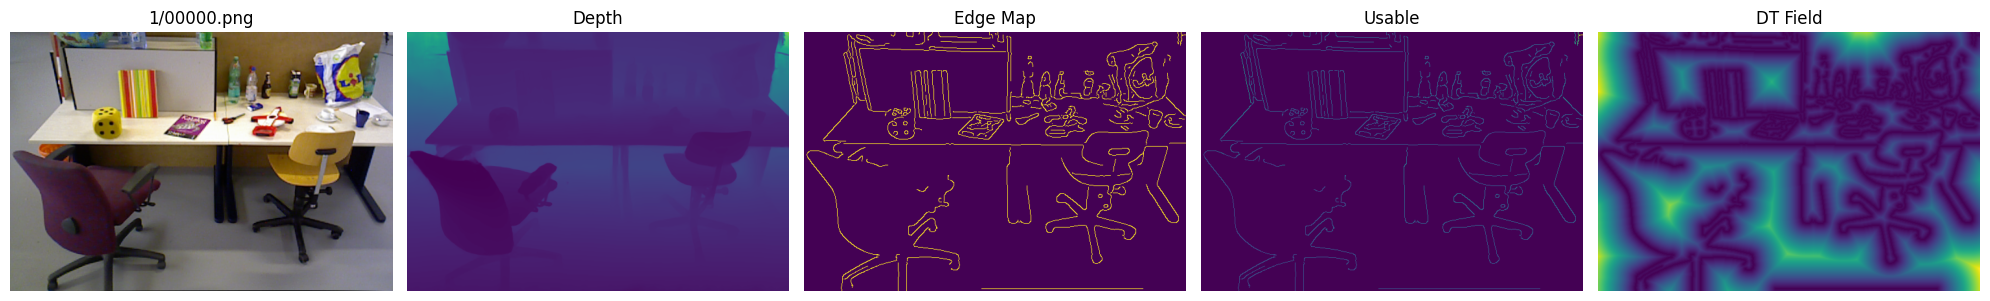

In [33]:
keys = sorted(list(adjuster.images.keys()))
print(adjuster.images[keys[0]].keys())

for i in range(0,150, 15):
    k = keys[i]
    rgb = adjuster.images[k]['image'].permute(1,2,0).cpu() if 'image' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).permute(1,2,0).cpu()
    depth = adjuster.images[k]['depth'].cpu() if 'depth' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
    edges_map =  adjuster.images[k]['edges_map'].cpu() if 'edges_map' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
    edges_map_mask = depth * adjuster.images[k]['edges_map'].cpu() if 'edges_map' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
    # conf = adjuster.images[k]['confidence'].cpu() if 'confidence' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
    # conf = (conf - conf.min()) / (conf.max() - conf.min() + 1e-8)
    dt_field = adjuster.images[k]['dt_field'].cpu() if 'dt_field' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
    plot_imgs([rgb, depth, edges_map, edges_map_mask, dt_field], titles=[k, "Depth", "Edge Map", "Usable", "DT Field"], figsize=(20,5))   
    break

# Use torch.nanmax() to ignore NaNs
# max_depths =  [torch.max(torch.nan_to_num(adjuster.images[k]["depth"], nan=-1.0)) for k in adjuster.images]
# print(max(max_depths).item())

In [34]:
adjuster(
    window_pose=25,
    window_depth=50,
    window_loss=100,
    convergence_tol_pose=0.5,  # relative change %
    convergence_tol_depth=0.1,  # relative change %
    convergence_tol_loss=1e-5,  # relative change %
    gt_path=gt_path, 
    debug=True,
    use_rerun =False,
    early_stop="pose", # whether to stop early if depth convergence is reached
)

Optimizing the scene:  20%|█▉        | 391/2000 [00:59<04:05,  6.55it/s]


In [35]:
opt = f"optimized_reconstruction_GD/seq_1"
os.makedirs(opt, exist_ok=True)

save_points = True # recall to set mean track len = 0 in colmap gui

adjuster.to_colmap(
    opt, 
    verbose=False, 
    max_points_per_image=100_000//len(adjuster.images), 
    save_points=save_points, 
    final_dbscan_filtering=False, 
    dbscan_eps=0.1, dbscan_min_samples=5,
    gt_path= gt_path
)

# # align to GT
# cmd = f"colmap model_aligner --input_path {opt} --output_path {opt} --ref_model_path {gt_path} --alignment_max_error 3"
# os.system(cmd)

# cmd = f"rm -rf {opt}/*.txt && colmap model_converter --input_path {opt} --output_path {opt} --output_type txt"

Reconstruction(num_cameras=1, num_images=50, num_reg_images=50, num_points3D=100000)

In [36]:
def align_trajectories(traj_pred, traj_gt):
        """
        Aligns traj_pred to traj_gt using Umeyama alignment (rotation, translation, scale).
        """
        # Calculate centroids
        mu_pred = traj_pred.mean(axis=0)
        mu_gt = traj_gt.mean(axis=0)

        # Center the trajectories
        pred_centered = traj_pred - mu_pred
        gt_centered = traj_gt - mu_gt

        # Singular Value Decomposition for Rotation
        H = pred_centered.T @ gt_centered
        U, S, Vt = np.linalg.svd(H)
        R = Vt.T @ U.T

        # Handle reflection case
        if np.linalg.det(R) < 0:
            Vt[2, :] *= -1
            R = Vt.T @ U.T

        # Calculate Scale
        var_pred = np.mean(np.linalg.norm(pred_centered, axis=1)**2)
        s = np.sum(S) / (len(traj_pred) * var_pred)

        # Calculate Translation
        t = mu_gt - s * R @ mu_pred

        # Transform predicted trajectory
        traj_pred_aligned = (s * R @ traj_pred.T).T + t
        return traj_pred_aligned
        
def get_camera_centers(reconstruction):
    """Extracts camera centers from a pycolmap reconstruction object."""
    centers = []
    # Sort by image name to ensure correspondence with ground truth
    img_ids = sorted(reconstruction.images.keys(), 
        key=lambda x: reconstruction.images[x].name)
        
    for img_id in img_ids:
        image = reconstruction.images[img_id]
        # Camera center in world coordinates: C = -R^T * t
        R = image.cam_from_world.rotation.matrix()
        t = image.cam_from_world.translation
        center = -R.T @ t
        centers.append(center)
    return np.array(centers)
    
def compute_rsm_ate(opt, gt_path):
    pred_recon = pycolmap.Reconstruction(opt)
    gt_recon = pycolmap.Reconstruction(gt_path)

    traj_pred = get_camera_centers(pred_recon)
    traj_gt = get_camera_centers(gt_recon)

    # --- NEW: Align before computing error ---
    traj_pred_aligned = align_trajectories(traj_pred, traj_gt)

    # Now compute error on the aligned trajectory
    errors = np.linalg.norm(traj_pred_aligned - traj_gt, axis=1)
        
    rms_ate = np.sqrt(np.mean(errors**2))
    return rms_ate

In [37]:
ts_GT_path = os.path.join(base_path ,"1", "synch.txt")

ts_opt_path = os.path.join( f"./{dataset_test}/{scene}_seq_1_opt.txt")


print(ts_GT_path)

image_to_ts_map = image_to_ts(ts_GT_path)

# Clear data
if os.path.exists(ts_opt_path):
    os.remove(ts_opt_path)

adjuster.to_TUM(
    image_to_ts_map,
    ts_opt_path
)

/media/leonardo/Leo_HD/data/EPO_track/TUM_RGBD/fr3_office/data/1/synch.txt


In [38]:
ts_GT_path = os.path.join(base_path, "1", "ts.txt")

print(f"RMSE for {dataset}/{scene}")
os.system(
    f"evo_ape tum {ts_GT_path} {ts_opt_path} -as -p --rerun"
)

RMSE for 0/fr3_office
APE w.r.t. translation part (m)
(with Sim(3) Umeyama alignment)

       max	0.018734
      mean	0.006172
    median	0.005574
       min	0.000507
      rmse	0.007484
       sse	0.002800
       std	0.004233



[2026-05-12T12:11:38Z INFO  winit::platform_impl::linux::x11::window] Guessed window scale factor: 1
[2026-05-12T12:11:39Z WARN  wgpu_hal::vulkan::instance] Unable to find extension: VK_EXT_physical_device_drm
libEGL warning: pci id for fd 27: 10de:2b85, driver (null)

pci id for fd 28: 10de:2b85, driver (null)
pci id for fd 29: 10de:2b85, driver (null)
libEGL warning: egl: failed to create dri2 screen
[2026-05-12T12:11:39Z INFO  re_grpc_server] Listening for gRPC connections on 0.0.0.0:9876. Connect by running `rerun --connect rerun+http://127.0.0.1:9876/proxy`
/home/leonardo/anaconda3/envs/EPO/lib/python3.10/site-packages/evo/tools/plot.py:233: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


0

# Add Frame test

In [39]:
import copy

#base_path = f"/media/leonardo/Leo_HD/data/EPO_track/TUM_RGBD/{scene}/seq_1/tracking"

image_path_t = os.path.join(base_path, "images")
depth_path_t = os.path.join(base_path, "depth_refined_h5")

reconstruction_path = os.path.join(base_path, "noisy_1")

GT_path = os.path.join(base_path, "1")

In [40]:
from helpers import load

new_indices = []

pose_noise = {}
pose_gt = {}
pose_noisy = {}

recon = pycolmap.Reconstruction(reconstruction_path)
images_recon = list(sorted(recon.images.values(), key=lambda x: x.name))

ts_path = os.path.join(base_path, "1", "synch.txt")

ts_opt_path = os.path.join( f"./{dataset_test}/{scene}_seq_1_traq.txt")


image_to_ts_map = image_to_ts(ts_path)

# Clear data
if os.path.exists(ts_opt_path):
    os.remove(ts_opt_path)

In [41]:
from tqdm import tqdm

from adjuster import FrameOptimizer

OPT_interval = 350
losses = []
mean_comp = []
mean_add_comp = []
mean_opt_comp = []

frameOptimizer = FrameOptimizer(
    adjuster=adjuster,
    window_size=10, 
    refinement_interval=350,
    frame_lr=3e-3, 
    refinement_iterations=100
)

all_images      = sorted(adjuster.recon.images.values(), key=lambda x: x.name)
tracking_frames = all_images[adjuster.n_mapping_frames:]

skip_count = 0

for idx, image_t in tqdm(enumerate(tracking_frames), desc= "sequence opt"): 

    camera_t =  image_t.camera
    image_name_t = image_t.name


    loss, comp_t, opt_t, add_t = frameOptimizer.track(
        image_path_t, 
        depth_path_t,
        image_name_t,
        camera_t,
        image_t
    )

    if not torch.is_tensor(loss):
        skip_count += 1
        continue

    losses.append(loss.detach().cpu().item() if loss.requires_grad else loss.cpu().item())
    mean_comp.append(comp_t)
    mean_add_comp.append(add_t)
    mean_opt_comp.append(opt_t)

    if((idx - skip_count) % 10 == 0 and (idx - skip_count) != 0):
        new_indices.append(image_name_t)

        frameOptimizer.adj.to_TUM(
            image_to_ts_map,
            ts_opt_path,
            new_indices
        )

sequence opt: 0it [00:00, ?it/s]/home/leonardo/Desktop/Code/EPO_SLAM/modules/camera.py:78: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  return self.cameras[indices]
sequence opt: 51it [00:22,  2.45it/s]

sequence opt: 222it [01:41,  2.38it/s]

sequence opt: 233it [01:46,  2.34it/s]

sequence opt: 244it [01:51,  2.31it/s]

sequence opt: 265it [02:01,  2.37it/s]

sequence opt: 562it [04:18,  2.17it/s]


KeyboardInterrupt: 

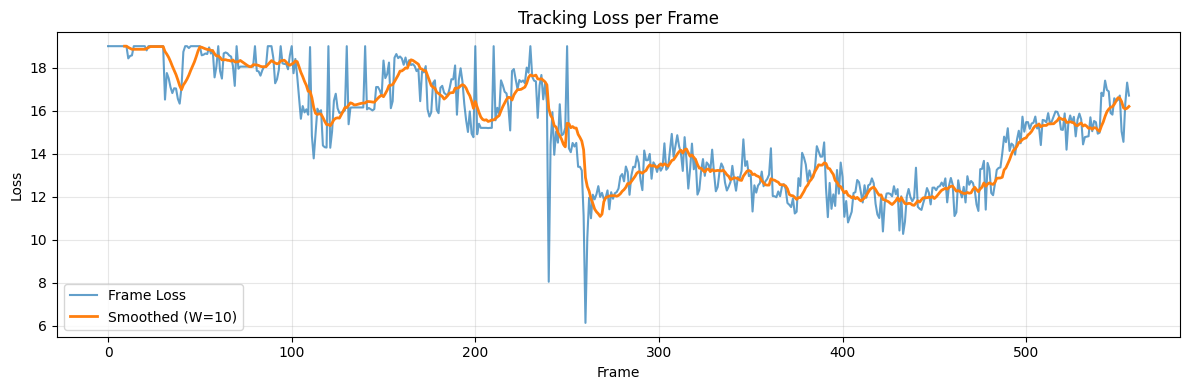

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(losses, label='Frame Loss', alpha=0.7)
smoothed = np.convolve(losses, np.ones(10)/10, mode='valid')
plt.plot(range(9, len(losses)), smoothed, label='Smoothed (W=10)', linewidth=2)
plt.xlabel('Frame')
plt.ylabel('Loss')
plt.title('Tracking Loss per Frame')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
print(adjuster.image_id_map)

{'1/00000.png': 0, '1/00001.png': 1, '1/00002.png': 2, '1/00003.png': 3, '1/00004.png': 4, '1/00005.png': 5, '1/00006.png': 6, '1/00007.png': 7, '1/00008.png': 8, '1/00009.png': 9, '1/00010.png': 10, '1/00011.png': 11, '1/00012.png': 12, '1/00013.png': 13, '1/00014.png': 14, '1/00015.png': 15, '1/00016.png': 16, '1/00017.png': 17, '1/00018.png': 18, '1/00019.png': 19, '1/00020.png': 20, '1/00021.png': 21, '1/00022.png': 22, '1/00023.png': 23, '1/00024.png': 24, '1/00025.png': 25, '1/00026.png': 26, '1/00027.png': 27, '1/00028.png': 28, '1/00029.png': 29, '1/00030.png': 30, '1/00031.png': 31, '1/00032.png': 32, '1/00033.png': 33, '1/00034.png': 34, '1/00035.png': 35, '1/00036.png': 36, '1/00037.png': 37, '1/00038.png': 38, '1/00039.png': 39, '1/00040.png': 40, '1/00041.png': 41, '1/00042.png': 42, '1/00043.png': 43, '1/00044.png': 44, '1/00045.png': 45, '1/00046.png': 46, '1/00047.png': 47, '1/00048.png': 48, '1/00049.png': 49, '1/00060.png': 50, '1/00070.png': 51, '1/00080.png': 52, '1

In [44]:
print(f"Average computation per frame: { np.mean(mean_comp)*1000:.2f} ms")
print(f"Average computation per adding: { np.mean(mean_add_comp)*1000:.2f} ms")
print(f"Average computation per optimization: { np.mean(mean_opt_comp)*1000:.2f} ms")

Average computation per frame: 84.31 ms
Average computation per adding: 41.38 ms
Average computation per optimization: 42.93 ms


In [45]:
# adjuster(
#     window_pose=25,
#     window_depth=50,
#     window_loss=100,
#     convergence_tol_pose=0.5,  # relative change %
#     convergence_tol_depth=0.1,  # relative change %
#     convergence_tol_loss=1e-5,  # relative change %
#     #gt_path=gt_path, 
#     debug=True,
#     use_rerun =False,
#     early_stop="none", # whether to stop early if depth convergence is reached
#     refinement = True,
#     refinement_iteration = 1000
# )

# # Clear data
# if os.path.exists(ts_opt_path):
#     os.remove(ts_opt_path)

# adjuster.to_TUM(
#     image_to_ts_map,
#     ts_opt_path
# )

Max AUC@5: 0.005933065280457271


/tmp/ipykernel_1501346/1641968781.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1501346/1641968781.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


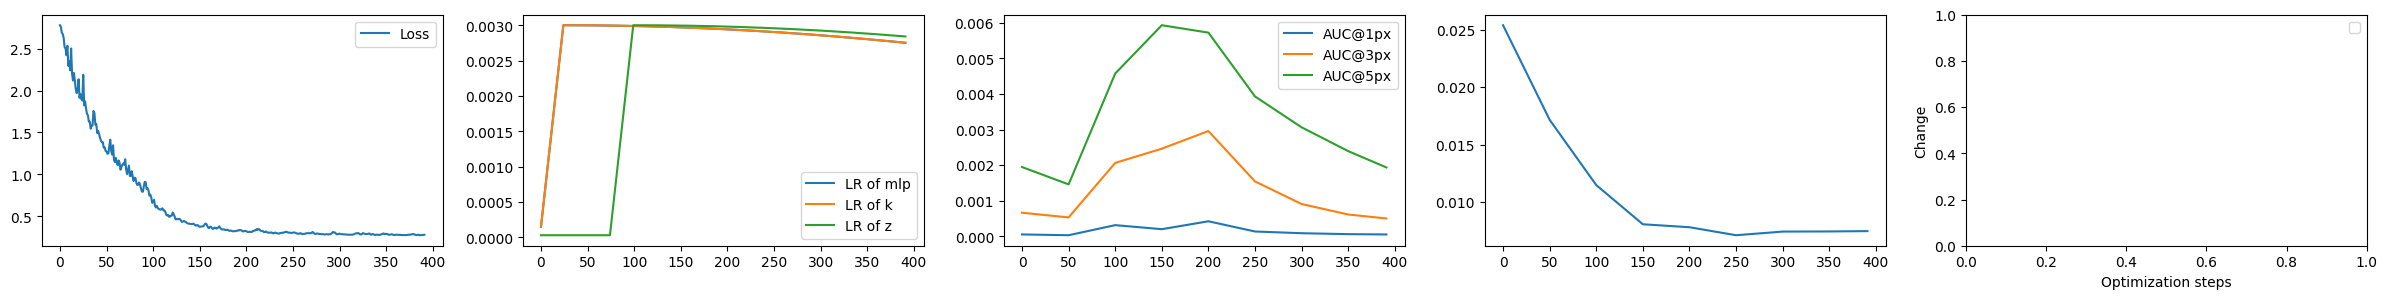

In [46]:
loss = adjuster.loss_list
lr_list = adjuster.lr_list
auc = adjuster.auc_list['auc']
print("Max AUC@5:", np.max(auc[5])) if len(auc[5]) > 0 else 0.0
# plot loss and lr side by side
n_plots = 5
plt.figure(figsize=(n_plots*6,3))
plt.subplot(1, n_plots, 1)
plt.plot(loss, label='Loss')
plt.legend()
plt.subplot(1, n_plots, 2)
for group, lr in lr_list.items():
    lr = np.array(lr)
    if len(lr) > 0:
        steps, lrs = lr[:,0],lr[:,1]
        plt.plot(steps, lrs, label=f'LR of {group}')
plt.legend()
plt.subplot(1, n_plots, 3)
for th in [1,3,5]: #adjuster.auc_th:
    plt.plot(adjuster.auc_list["steps"], auc[th], label=f'AUC@{th}px')
plt.legend() if len(adjuster.auc_list) > 0 else None
plt.subplot(1, n_plots, 4)
plt.plot(adjuster.rms_ate_list["steps"], adjuster.rms_ate_list["rms_ate"], label=f'RMSE ATE')

plt.subplot(1, n_plots, 5)
#plt.plot(adjuster.changes["steps"], adjuster.changes["q"], label='Rotation change (deg)')
#plt.plot(adjuster.changes["steps"], adjuster.changes["t"], label='Translation change (m)')
#plt.plot(adjuster.changes["steps"], adjuster.changes["max"], label='Max change')

plt.xlabel('Optimization steps')
plt.ylabel('Change')
plt.legend()
plt.legend()
plt.show()

In [47]:
ts_GT_path = os.path.join(base_path, "1", "ts.txt")

pdf_path = os.path.join("./evo_test", f"{scene}_track_{int(time.time())}.pdf")


# os.system(
#     f"evo_ape tum {ts_GT_path} {ts_opt_path} --save_plot {pdf_path} -as -p"
# )


os.system(
    f"evo_ape tum {ts_GT_path} {ts_opt_path} -as -p --rerun"
)

APE w.r.t. translation part (m)
(with Sim(3) Umeyama alignment)

       max	2.200622
      mean	0.878438
    median	0.817030
       min	0.303155
      rmse	0.984774
       sse	53.337931
       std	0.445114



[2026-05-12T12:16:03Z INFO  winit::platform_impl::linux::x11::window] Guessed window scale factor: 1
[2026-05-12T12:16:03Z WARN  wgpu_hal::vulkan::instance] Unable to find extension: VK_EXT_physical_device_drm
libEGL warning: pci id for fd 27: 10de:2b85, driver (null)

pci id for fd 28: 10de:2b85, driver (null)
pci id for fd 29: 10de:2b85, driver (null)
libEGL warning: egl: failed to create dri2 screen
[2026-05-12T12:16:04Z INFO  re_grpc_server] Listening for gRPC connections on 0.0.0.0:9876. Connect by running `rerun --connect rerun+http://127.0.0.1:9876/proxy`
/home/leonardo/anaconda3/envs/EPO/lib/python3.10/site-packages/evo/tools/plot.py:233: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


0

In [48]:
# Clear data
if os.path.exists(ts_opt_path):
    os.remove(ts_opt_path)

frameOptimizer.adj.to_TUM(
            image_to_ts_map,
            ts_opt_path,
            new_indices[11:]
        )


In [49]:
# os.system(
#     f"evo_rpe tum {ts_GT_path} {ts_opt_path} -as -p --rerun"
# )

In [50]:
print(ts_opt_path)

./TUM_RGBD/fr3_office_seq_1_traq.txt


In [51]:
print(ts_GT_path)

/media/leonardo/Leo_HD/data/EPO_track/TUM_RGBD/fr3_office/data/1/ts.txt


In [52]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)